In [154]:
import numpy as np
import seaborn as sns
import pandas as pd

In [155]:
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]

user_cols = ["user_id" ,"age", "gender" , "occupation" , "zip code"]

movies_col_names = ["movie_id", "title", "release_date", "video_release_date", "IMDb_URL"] + genre_cols

ratings_cols = ["user_id", "movie_id", "rating", "timestamp"]

movies = pd.read_csv(
    "../src/data/ml-100k/u.item",
    sep="|",
    header=None,
    names=movies_col_names,
    encoding="latin-1",
)

users = pd.read_csv(
    "../src/data/ml-100k/u.user",
    sep="|",
    header=None,
    names= user_cols,
    encoding="latin-1",
)

ratings = pd.read_csv(
    "../src/data/ml-100k/u.data",
    sep="\t",
    header=None,
    names= ratings_cols,
    encoding="latin-1",
)

Text(0.5, 1.0, 'Quantidade x Gênero')

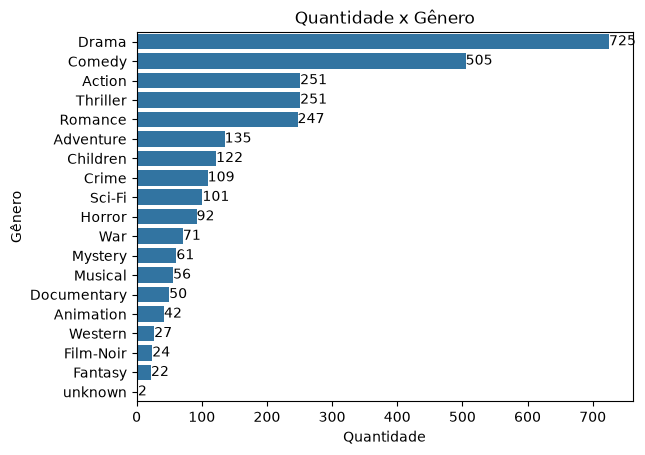

In [156]:
sorted_movies_by_genre = movies[genre_cols].sum().sort_values(ascending= False)
ax = sns.barplot(x= sorted_movies_by_genre.values, y= sorted_movies_by_genre.index)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Quantidade")
ax.set_ylabel("Gênero")
ax.set_title('Quantidade x Gênero')

[Text(0, 0, '670'), Text(0, 0, '273')]

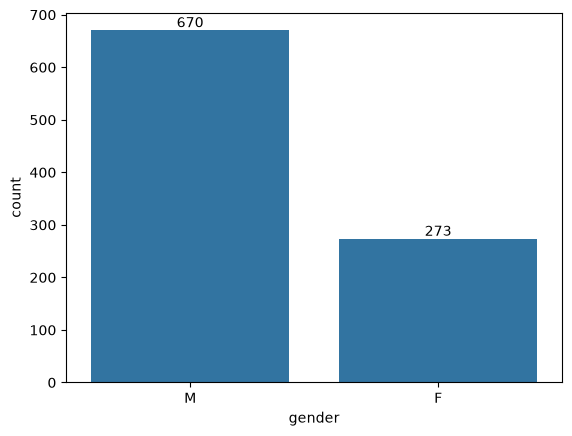

In [157]:
ax = sns.countplot(data=users, x="gender")
ax.bar_label(ax.containers[0])

Text(0.5, 1.0, 'Quantidade x Ocupação')

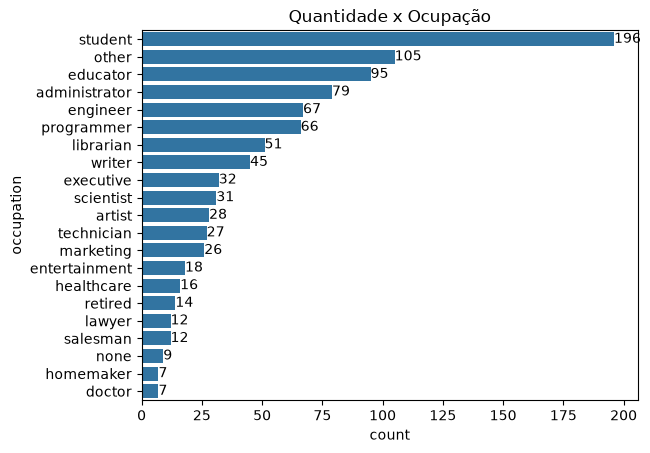

In [158]:
ordem = users["occupation"].value_counts().index

ax = sns.countplot(data=users, y="occupation", order=ordem)
ax.bar_label(ax.containers[0])
ax.set_title("Quantidade x Ocupação")

[Text(0, 0, '54'),
 Text(0, 0, '218'),
 Text(0, 0, '299'),
 Text(0, 0, '182'),
 Text(0, 0, '85'),
 Text(0, 0, '59'),
 Text(0, 0, '46')]

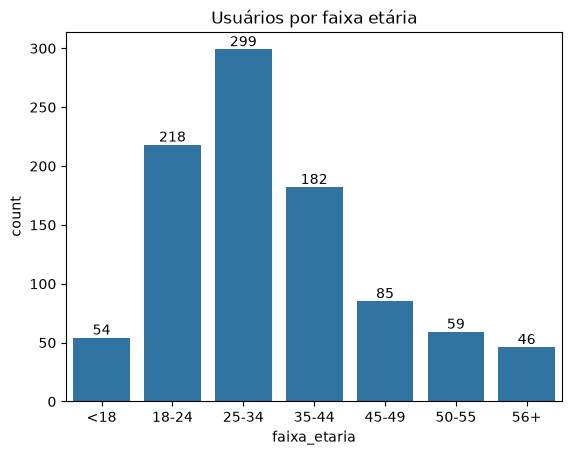

In [159]:
faixas = [0, 18, 25, 35, 45, 50, 56, 100]
rotulos = ["<18", "18-24", "25-34", "35-44", "45-49", "50-55", "56+"]

users["faixa_etaria"] = pd.cut(users["age"], bins=faixas, labels=rotulos)
ordem = ["<18", "18-24", "25-34", "35-44", "45-49", "50-55", "56+"]

ax = sns.countplot(data=users, x="faixa_etaria", order=ordem)
ax.set_title("Usuários por faixa etária")
ax.bar_label(ax.containers[0])

Text(0.5, 1.0, 'Filmes  mais avaliados')

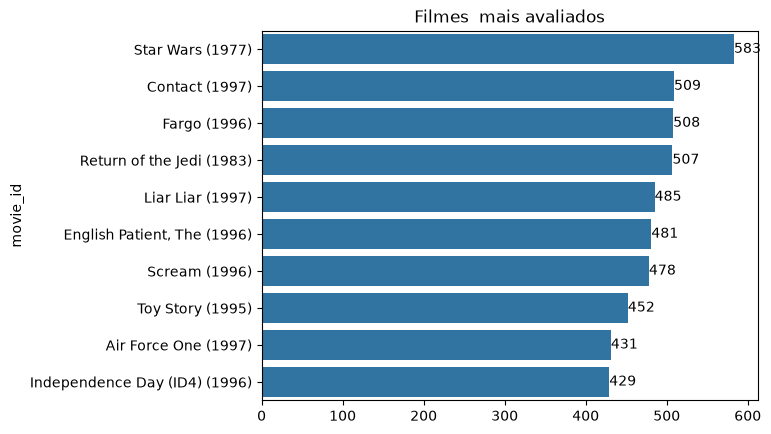

In [175]:
top = ratings["movie_id"].value_counts().sort_values(ascending=False).head(10)
titulos = movies.set_index("movie_id")["title"]

ax = sns.barplot(x=top.values, y=top.index.map(titulos))
ax.bar_label(ax.containers[0])
ax.set_title("Filmes  mais avaliados")